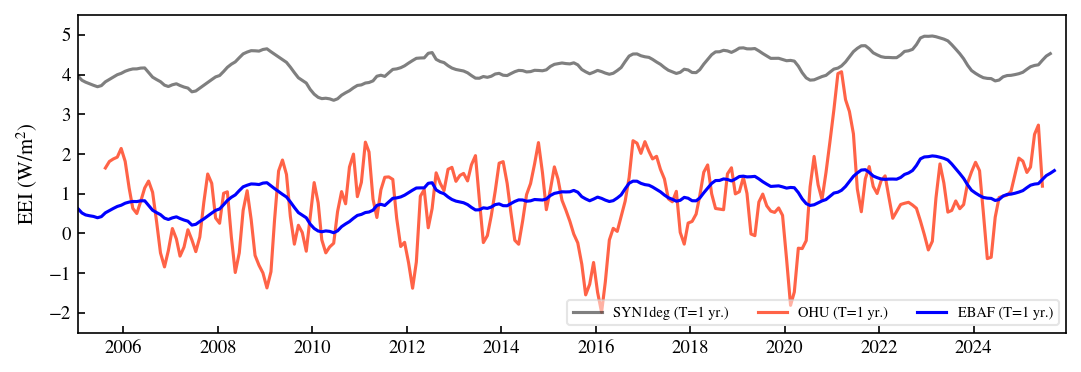

In [9]:
# figure for FINESST
import sys, os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import RegularLatLonGrid
from SpaceBalls.utils import normal_smoother, normal_smoother_uneven, normal_smoother_uneven_2
from SpaceBalls.paths import MEDIA_DIR
import pandas as pd
from config.constants import earth_radius
RE = earth_radius(units='m')
S = 4 * np.pi * RE**2
base_dir = os.path.join(MEDIA_DIR, 'true_EEI', 'ceres_dataproducts')

ohc_fname = 'monthly-ocean-heat-2000m.csv'
ohc_dataset = pd.read_csv(os.path.join(base_dir, ohc_fname), sep=',', header=0) #np.loadtxt(os.path.join(base_dir, ohc_fname), skiprows=1, delimiter=',')
ohc_dataset
dates = pd.to_datetime(ohc_dataset['Day'])
dates = np.array(dates)
time_array = np.asarray(dates, dtype=np.float64)  # nanoseconds
time_array = (time_array - time_array[0]) /1e9
time_array_days = time_array / 3600 / 24
ohc_array = np.array(ohc_dataset['Monthly average ocean heat content for the 0-2000 meters layer']) *1e22 # Joules
ohu = np.gradient(ohc_array, time_array) /S / 0.9

ceres_grid = RegularLatLonGrid(alt_km=0, n_lat=180, n_lon=360)

ebaf_fname = 'CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202604.nc'
syn1deg_fname_1 = 'CERES_SYN1deg-Month_Terra-Aqua-NOAA20_Ed4.2_Subset_200003-202603.nc'

ebaf_dataset = xr.open_dataset(os.path.join(base_dir, ebaf_fname))
time_ebaf = ebaf_dataset['time'].to_numpy()
time_ebaf_days = (time_ebaf - time_ebaf[0]) / (1e9 * 24 * 3600)
net_ebaf = ebaf_dataset['toa_net_all_mon'].to_numpy()
month_eei_ebaf = ceres_grid.compute_surf_integral(np.moveaxis(net_ebaf, 0, -1), average=True)
yr_eei_ebaf = normal_smoother_uneven_2(month_eei_ebaf, time_ebaf_days, 365.24, out_length_mode='same_with_nans')

ebaf_fname_global = 'CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202604_globalmean.nc'
ebaf_dataset_global = xr.open_dataset(os.path.join(base_dir, ebaf_fname_global))
month_eei_ebaf_gloabl = ebaf_dataset_global['gtoa_net_all_mon'].to_numpy()
yr_eei_ebaf_global = normal_smoother_uneven_2(month_eei_ebaf_gloabl, time_ebaf_days, 365.24, out_length_mode='same_with_nans')

syn1deg_dataset_1 = xr.open_dataset(os.path.join(base_dir, syn1deg_fname_1))
time_syn1deg = syn1deg_dataset_1['time'].to_numpy()
time_syn1deg_days = (time_syn1deg - time_syn1deg[0]) / (1e9 * 24 * 3600)
net_syn1deg = syn1deg_dataset_1['toa_net_all_mon'].to_numpy()
month_eei_syn1deg = ceres_grid.compute_surf_integral(np.moveaxis(net_syn1deg, 0, -1), average=True)
yr_eei_syn1deg = normal_smoother(month_eei_syn1deg, np.arange(len(month_eei_syn1deg)), 12, out_length_mode='same_with_nans')

syn1deg_fname_1_global = 'CERES_SYN1deg-Month_Terra-Aqua-NOAA20_Ed4.2_Subset_200003-202603_globalmean.nc'
syn1deg_dataset_1_global = xr.open_dataset(os.path.join(base_dir, syn1deg_fname_1_global))
net_syn1deg_global = syn1deg_dataset_1_global['gtoa_net_all_mon'].to_numpy()
yr_eei_syn1deg_global = normal_smoother_uneven_2(net_syn1deg_global, time_syn1deg_days, 365.24, out_length_mode='same_with_nans')

fig, ax = plt.subplots(figsize=(8.5, 2.75))
#fig, ax = plt.subplots(figsize=(10,2.5))
#ax.plot(time_syn1deg, month_eei_syn1deg, color='k', lw=0.5, alpha=0.5, label='SYN1deg (T=1 mo.)')
ax.plot(time_syn1deg, yr_eei_syn1deg_global,  color='k', alpha=0.5, label='SYN1deg (T=1 yr.)')

ohu_smooth = normal_smoother_uneven_2(ohu, time_array_days, 365.24, out_length_mode='same_with_nans')

#ax.plot(dates, ohu, color='tomato', lw=0.5, alpha=0.5, label='OHU (T=1 mo.)')

#ax.plot(time_ebaf, month_eei_ebaf, color='b', lw=0.5, alpha=0.5, label='EBAF (T=1 mo.)')
#ax.plot(time_ebaf, yr_eei_ebaf, color='b', label='EBAF (T=1 yr.)')

ax.plot(dates, ohu_smooth, color='tomato', label='OHU (T=1 yr.)')
ax.plot(time_ebaf, yr_eei_ebaf_global, color='b', label='EBAF (T=1 yr.)')
ax.set_ylim([-2.5, 5.5])

ax.set_ylabel('EEI (W/m$^2$)')
ax.set_xlim([dates[0], dates[-1]])
#ax.set_yscale('symlog', linthresh=2)
ax.legend(fontsize='x-small', ncols=3, loc='lower right', 
    frameon=True,      # Enable the legend box
    framealpha=0.5,    # Transparency (0 = fully transparent, 1 = opaque)
    facecolor='white', # Background color
    edgecolor=None   # Border color)
)



In [ ]:

fig.savefig('EEI_comparison.pdf')

In [ ]:
time_ebaf_days = (time_ebaf - time_ebaf[0]) / (1e9 * 24 * 3600)

array([   0,   31,   61,   92,  122,  153,  184,  214,  245,  275,  306,
        337,  365,  396,  426,  457,  487,  518,  549,  579,  610,  640,
        671,  702,  730,  761,  791,  822,  852,  883,  914,  944,  975,
       1005, 1036, 1067, 1095, 1126, 1156, 1187, 1217, 1248, 1279, 1309,
       1340, 1370, 1401, 1432, 1461, 1492, 1522, 1553, 1583, 1614, 1645,
       1675, 1706, 1736, 1767, 1798, 1826, 1857, 1887, 1918, 1948, 1979,
       2010, 2040, 2071, 2101, 2132, 2163, 2191, 2222, 2252, 2283, 2313,
       2344, 2375, 2405, 2436, 2466, 2497, 2528, 2556, 2587, 2617, 2648,
       2678, 2709, 2740, 2770, 2801, 2831, 2862, 2893, 2922, 2953, 2983,
       3014, 3044, 3075, 3106, 3136, 3167, 3197, 3228, 3259, 3287, 3318,
       3348, 3379, 3409, 3440, 3471, 3501, 3532, 3562, 3593, 3624, 3652,
       3683, 3713, 3744, 3774, 3805, 3836, 3866, 3897, 3927, 3958, 3989,
       4017, 4048, 4078, 4109, 4139, 4170, 4201, 4231, 4262, 4292, 4323,
       4354, 4383, 4414, 4444, 4475, 4505, 4536, 45

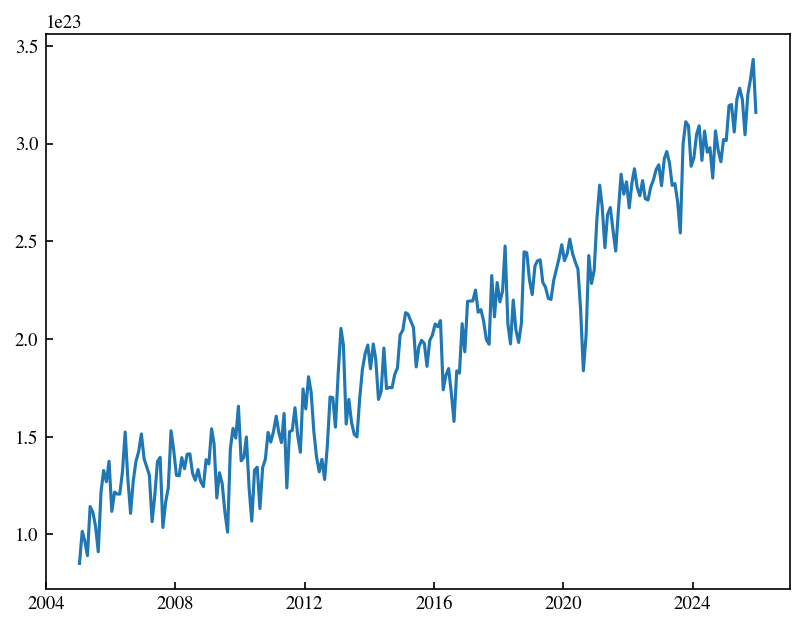

In [4]:

plt.plot(dates, ohc_array)

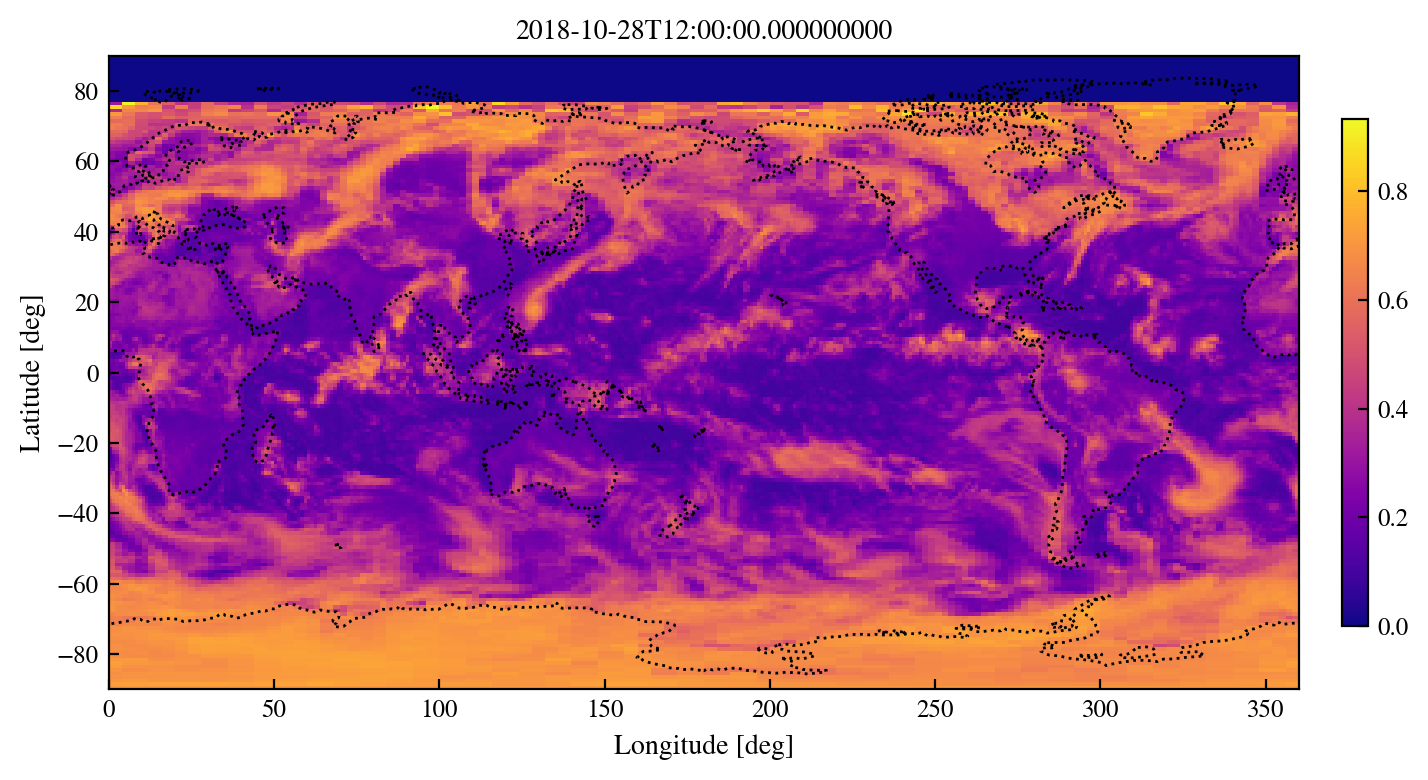

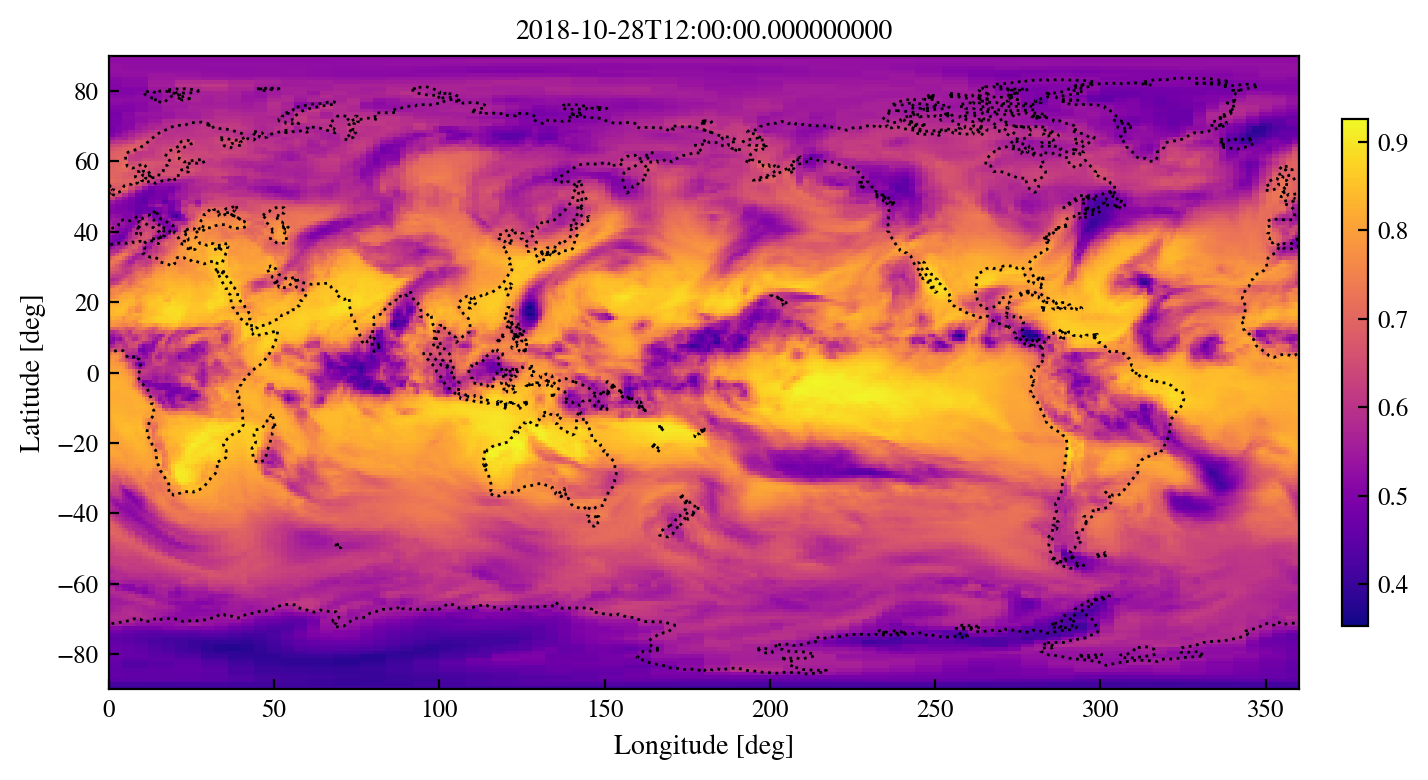

In [1]:
import sys, os
import xarray as xr
import numpy as np
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import RegularLatLonGrid
from SpaceBalls.paths import MEDIA_DIR

ceres_grid = RegularLatLonGrid(alt_km=0, n_lat=180, n_lon=360)
base_dir = os.path.join(MEDIA_DIR, 'true_EEI', 'ceres_dataproducts')

day_idx = 300
ebaf_fname = 'CERES_EBAF-TOA_Ed4.2.1_Subset_201801-202512.nc'
syn1deg_fname_1 = 'CERES_SYN1deg-Day_Terra-Aqua-NOAA20_Ed4.2_Subset_20180101-20220105.nc'

ebaf_dataset = xr.open_dataset(os.path.join(base_dir, ebaf_fname))

syn1deg_dataset_1 = xr.open_dataset(os.path.join(base_dir, syn1deg_fname_1))
time_array = syn1deg_dataset_1['time'].to_numpy()
sw_daily_array = syn1deg_dataset_1['toa_sw_all_daily'].to_numpy()
a_daily_array = syn1deg_dataset_1['toa_alb_all_daily'].to_numpy()
a_daily_array[np.isnan(a_daily_array)] = 0

lw_daily_array = syn1deg_dataset_1['toa_lw_all_daily'].to_numpy()
solar_daily_array = syn1deg_dataset_1['toa_solar_all_daily'].to_numpy()
avg_solar_daily_array = ceres_grid.compute_surf_integral(np.moveaxis(solar_daily_array, 0, -1), average=True)
e_daily_array = lw_daily_array / avg_solar_daily_array[:,None,None]

Plotter.plot_geo_data_new(np.flipud(a_daily_array[day_idx,:,:]), ceres_grid, 
                          make_symmetric_cmap=False, add_coastlines=True, title=time_array[day_idx])

Plotter.plot_geo_data_new(np.flipud(e_daily_array[day_idx,:,:]), ceres_grid, 
                          make_symmetric_cmap=False, add_coastlines=True, title=time_array[day_idx])

In [ ]:
from SpaceBalls.sph_meshing import fit_sh_field, expand_sh
day_idx = 0
a_day = np.flipud(a_daily_array[day_idx,:,:])
sh_a = fit_sh_field(grid.vectorize_if_needed(a_day), grid.stacked_grid_latlon[:,1], 
                  grid.stacked_grid_latlon[:,0], lmax=180)



In [2]:
import numpy as np
from SpaceBalls.sph_meshing import fit_sh_field, expand_sh
lmax = 179
day_idx = 0

e_day = np.flipud(e_daily_array[day_idx,:,:])
sh_e = fit_sh_field(grid.vectorize_if_needed(e_day), grid.stacked_grid_latlon[:,1], 
                  grid.stacked_grid_latlon[:,0], lmax=lmax)



 Warning --- SHExpandLSQ
 Consider changing parameter value of OPT to          128  and recompiling the SHTOOLS archive.


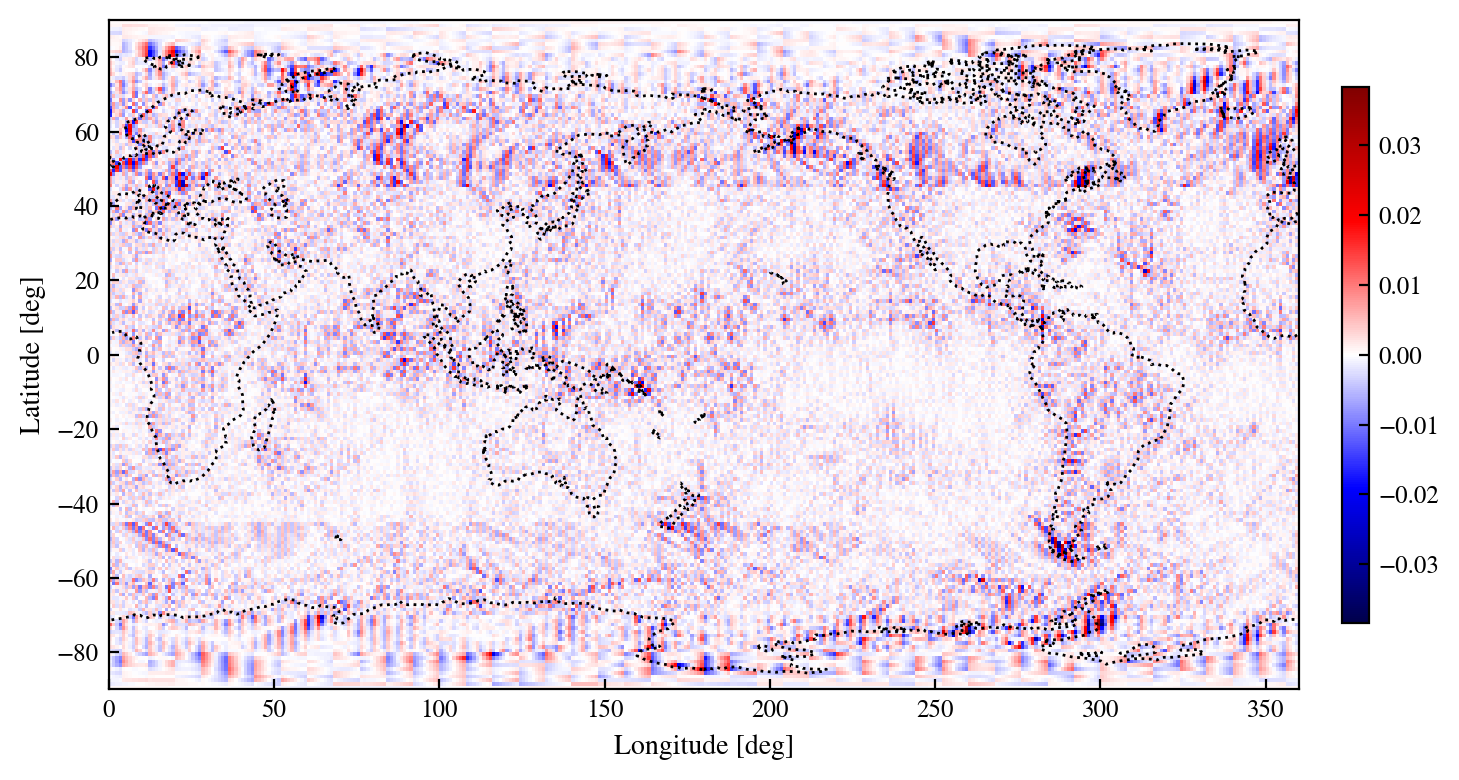

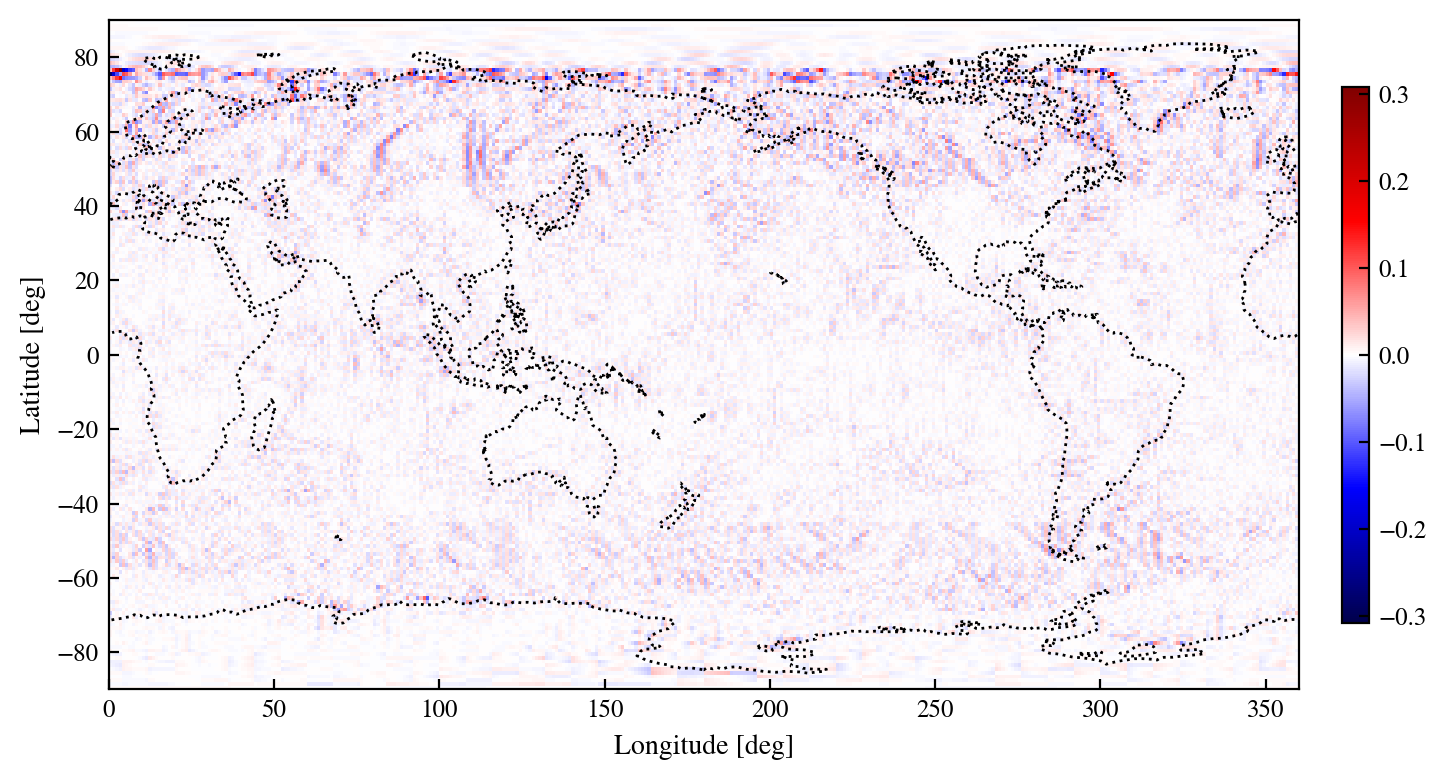

In [ ]:
import SpaceBalls.radiation_settings as rad_settings
import pyshtools as pysh

mode="SYN1deg_fine"
datestr = np.datetime_as_string(time_array[day_idx], unit='D') #'2018-06-25'
a_sh_coeffs, e_sh_coeffs = rad_settings.get_ae_sh_maps_numpy_new(mode, datestr)
a_sh_map = pysh.SHCoeffs.from_array(a_sh_coeffs) # , normalization='unnorm')
e_sh_map = pysh.SHCoeffs.from_array(e_sh_coeffs) # , normalization='unnorm')

expanded_e_sh_map = e_sh_map.expand(lat=ceres_grid.stacked_grid_latlon[:,0], 
                                    lon=ceres_grid.stacked_grid_latlon[:,1])
expanded_e_diff = np.reshape(expanded_e_sh_map, (180,360)) - np.flipud(e_daily_array[day_idx,:,:])

expanded_a_sh_map = a_sh_map.expand(lat=ceres_grid.stacked_grid_latlon[:,0], 
                                    lon=ceres_grid.stacked_grid_latlon[:,1])
expanded_a_diff = np.reshape(expanded_a_sh_map, (180,360)) - np.flipud(a_daily_array[day_idx,:,:])

Plotter.plot_geo_data_new(expanded_e_diff, ceres_grid, make_symmetric_cmap=True,
                          add_coastlines=True)
Plotter.plot_geo_data_new(expanded_a_diff, ceres_grid, make_symmetric_cmap=True,
                          add_coastlines=True)

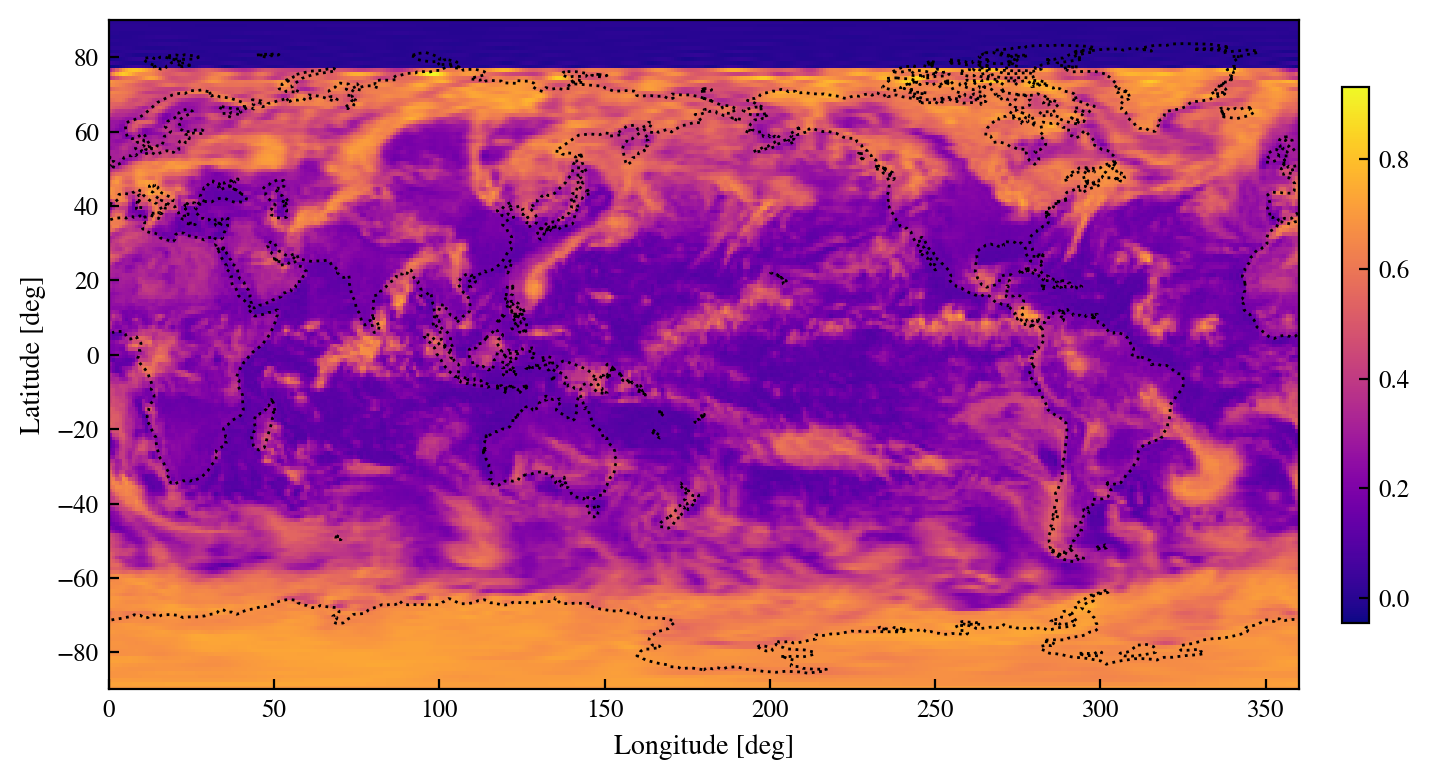

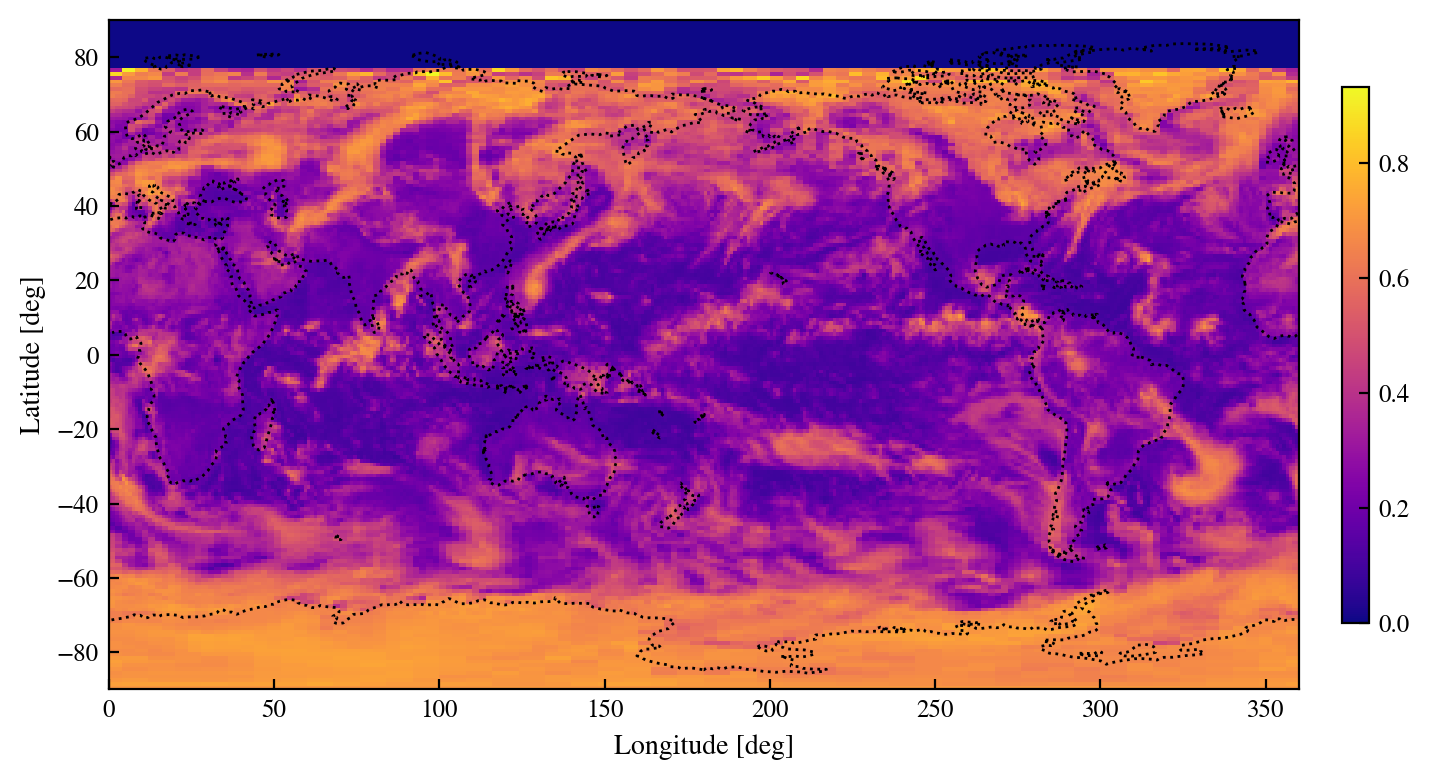

In [3]:
Plotter.plot_geo_data_new(expanded_a_sh_map, ceres_grid, make_symmetric_cmap=False,
                          add_coastlines=True)

Plotter.plot_geo_data_new(np.flipud(a_daily_array[day_idx,:,:]), ceres_grid, make_symmetric_cmap=False,
                          add_coastlines=True)

In [22]:
print(e_sh_coeffs[0,0,0])
print(sh_e.coeffs[0,0,0])

0.6931119818894091
0.6706040571470695


In [3]:
grid_glq = RegularLatLonGrid(0, lmax=52, quad_type='GLQ')
expanded_e_glq = sh_e.expand(lat=grid_glq.stacked_grid_latlon[:,0], lon=grid_glq.stacked_grid_latlon[:,1], 
                         lmax=lmax)
print(f"N points: {grid_glq.n_points}")

grid_reg = RegularLatLonGrid(0, n_lat=grid_glq.n_lat, n_lon=grid_glq.n_lon)
expanded_e = sh_e.expand(lat=grid_reg.stacked_grid_latlon[:,0], lon=grid_reg.stacked_grid_latlon[:,1], 
                         lmax=lmax)


N points: 5565


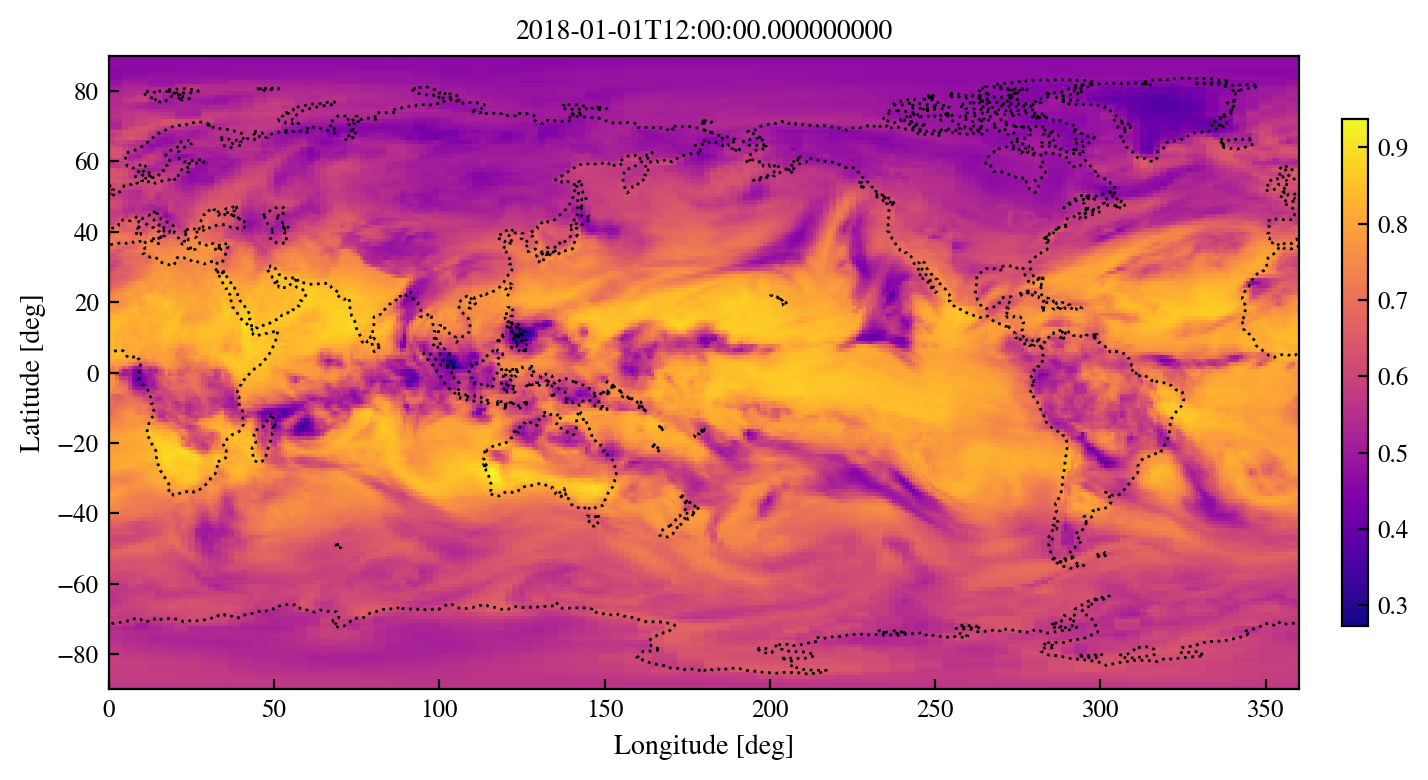

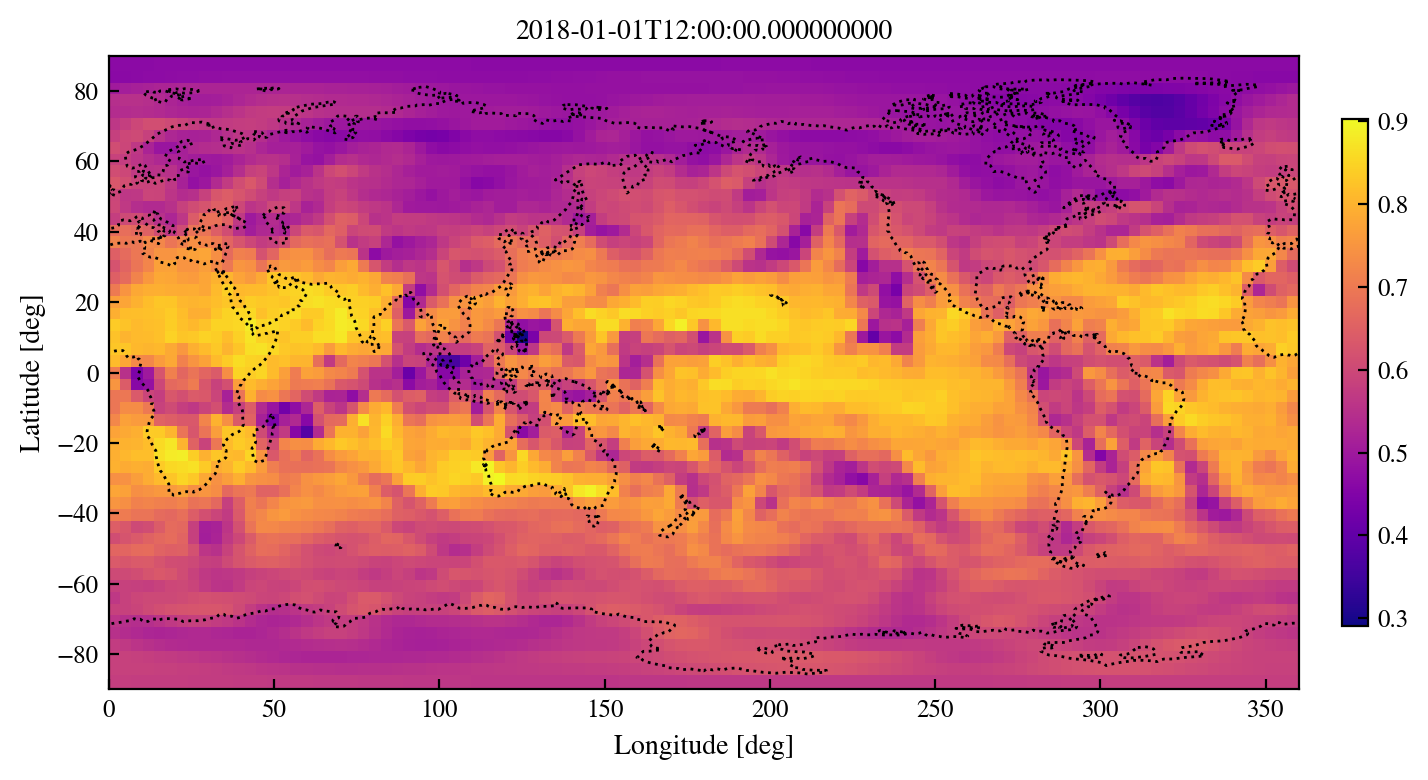

In [34]:

Plotter.plot_geo_data_new(e_day, grid, 
                          make_symmetric_cmap=False, add_coastlines=True, title=time_array[0])
Plotter.plot_geo_data_new(grid_reg.reshape_if_needed(expanded_e), grid_glq,
                          make_symmetric_cmap=False, add_coastlines=True, title=time_array[0])

In [39]:
avg_reg = grid_reg.compute_surf_integral(grid_reg.reshape_if_needed(expanded_e), average=True)
avg_glq = grid_glq.compute_surf_integral(grid_glq.reshape_if_needed(expanded_e_glq), average=True)
avg_true = sh_e.coeffs[0,0,0]
avg_ceres = grid.compute_surf_integral(e_daily_array[day_idx,:,:], average=True)

print(f"Direct integral from 1deg x 1deg dataproduct: {avg_ceres}")
print(f"Numeric integral in regular grid: {avg_reg}")
print(f"Numeric integral in GLQ grid: {avg_glq}")
print(f"Actual C00: {avg_true}")

Direct integral from 1deg x 1deg dataproduct: 0.6706021011553889
Numeric integral in regular grid: 0.6705809909016
Numeric integral in GLQ grid: 0.6706042730422566
Actual C00: 0.6706042730422572


In [37]:
print(f"Error reg grid integral: {avg_reg - avg_true}")
print(f"Error GLQ grid integral: {avg_glq - avg_true}")

Error reg grid integral: -2.3282140657276962e-05
Error GLQ grid integral: -6.661338147750939e-16


In [40]:
print(f"Error reg grid integral: {avg_reg - avg_ceres}")
print(f"Error GLQ grid integral: {avg_glq - avg_ceres}")

Error reg grid integral: -2.111025378892517e-05
Error GLQ grid integral: 2.1718868676856573e-06


In [17]:
finest_regular_grid = RegularLatLonGrid(0, n_lat=180*16, n_lon=360*16)
print(f"N points reg: {finest_regular_grid.n_points}")

finest_glq_grid = RegularLatLonGrid(0, lmax=2500, quad_type='GLQ')
print(f"N points GLQ: {finest_glq_grid.n_points}")

N points reg: 16588800
N points GLQ: 12507501


In [ ]:
Plotter.plot_geo_data_new(e_day-grid.reshape_if_needed(expanded_e), grid, 
                          make_symmetric_cmap=True, add_coastlines=True, title=time_array[0])


In [ ]:
from SpaceBalls.sph_meshing import RegularLatLonGrid, get_pysh_grid
from SpaceBalls.utils import unique_with_tolerance
import numpy as np

lmax = 15
glq_grid = RegularLatLonGrid(alt_km=0, lmax=lmax, quad_type='GLQ')
pysh_grid = get_pysh_grid('GLQ', lmax)

pysh_weights = pysh_grid.weights / (glq_grid.n_lon)

weights = glq_grid.integration_weights /( glq_grid.total_area/(4* np.pi))
lats = glq_grid.stacked_grid_latlon[:,0]
_, idxs = np.unique(lats, return_index=True)
weights = weights[idxs]

pysh_weights = unique_with_tolerance(pysh_weights, 1e-6)
weights = unique_with_tolerance(weights, 1e-6)

print(pysh_weights)
print(weights)
print(weights/pysh_weights)



#print(weights - pysh_weights)


In [ ]:
from SpaceBalls.sph_meshing import get_spherical_grid_cell_areas

areas = get_spherical_grid_cell_areas(glq_grid.lat_edges_vec, 
                                      glq_grid.lon_edges_vec)
areas_lat_rings = np.sum(areas, axis=1)
weights_pyshtools_guess = areas_lat_rings / (glq_grid.total_area/2)
weights_pyshtools_guess

In [ ]:
(weights_pyshtools_guess - pysh_grid.weights) / weights_pyshtools_guess

In [ ]:
pysh_grid = get_pysh_grid('GLQ', 179)
pysh_grid.lats()

In [ ]:
import pyshtools as pysh

grid_types = ['DH', 'GLQ']

for i in range(131):
    for grid_type in grid_types:
        grid = pysh.SHGrid.from_zeros(lmax=i, grid=grid_type)
        print(f"N points for {grid_type} of order {i}: {grid.nlat * grid.nlon}")


In [ ]:
pysh.SHGrid.from_array()
pysh.SHCoeffs.from_cap()